In [1]:
import os
import pandas as pd
import numpy as np
import importlib
import pickle

from Soccer_OCEL.idsse_import import get_games, load_game_data
from Soccer_OCEL.role_objects import assign_roles_multi, assign_roles
import Soccer_OCEL.utils as utils
import Soccer_OCEL.soccer_plot as plot
import Soccer_OCEL.trajectory_clustering as tc

import geopandas as gpd
import shapely.geometry as geometries
from Soccer_OCEL.soccer_plot import plot_background_ax, fastplot, plot_background, plot_trace, add_legend, add_event

from shapely.geometry import Polygon, LineString, Point

import matplotlib.pyplot as plt

In [2]:
path='data/28196177'
games=['J03WQQ', 'J03WPY', 'J03WOH', 'J03WOY']
GDs=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}.pkl"), "rb") as f:
        GameData = pickle.load(f)
    flagged_df=tc.trajectory_anom_full_game(GameData)
    flagged_df.to_csv(os.path.join("output","output_cluster",Game+".csv"), index=False)
    GDs.append(GameData)

Processing: J03WQQ_Away_1
  Auto-selected eps=0.2878, silhouette=0.286, clusters=2, outliers=0
Processing: J03WQQ_Away_100
  Downsampled 296 → 148 frames (factor=2)
  Auto-selected eps=0.3600, silhouette=0.197, clusters=3, outliers=0
Processing: J03WQQ_Away_101
  Downsampled 494 → 165 frames (factor=3)
  Auto-selected eps=0.4748, silhouette=0.324, clusters=2, outliers=0
Processing: J03WQQ_Away_104
  Auto-selected eps=0.1635, silhouette=0.313, clusters=5, outliers=0
Processing: J03WQQ_Away_107
  Downsampled 298 → 149 frames (factor=2)
  Auto-selected eps=0.3091, silhouette=0.232, clusters=4, outliers=0
Processing: J03WQQ_Away_109
  Downsampled 1971 → 132 frames (factor=15)
  Auto-selected eps=0.6021, silhouette=0.222, clusters=3, outliers=0
Processing: J03WQQ_Away_11
  Downsampled 431 → 144 frames (factor=3)
  Auto-selected eps=0.4278, silhouette=0.178, clusters=2, outliers=0
Processing: J03WQQ_Away_111
  Downsampled 357 → 179 frames (factor=2)
  Auto-selected eps=0.5856, silhouette=0.2

In [2]:
path='data/28196177'
#games=get_games(path)
games=['J03WR9']
#games=['J03WQQ', 'J03WR9']#, 'J03WPY', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
#games=['J03WR9', 'J03WPY']#Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}.pkl"), "rb") as f:
        GameData = pickle.load(f)
        GameData.format_log('ALL')
#     all_games.append(GameData.events)
# allgame_df=pd.concat(all_games).sort_values(['attribute:session','attribute:frame']).reset_index(drop=True)
# GameData=assign_roles(GameData, process_DF='TEAMSHEET')

  Auto-selected eps=0.2819, silhouette=0.414, clusters=4, outliers=0


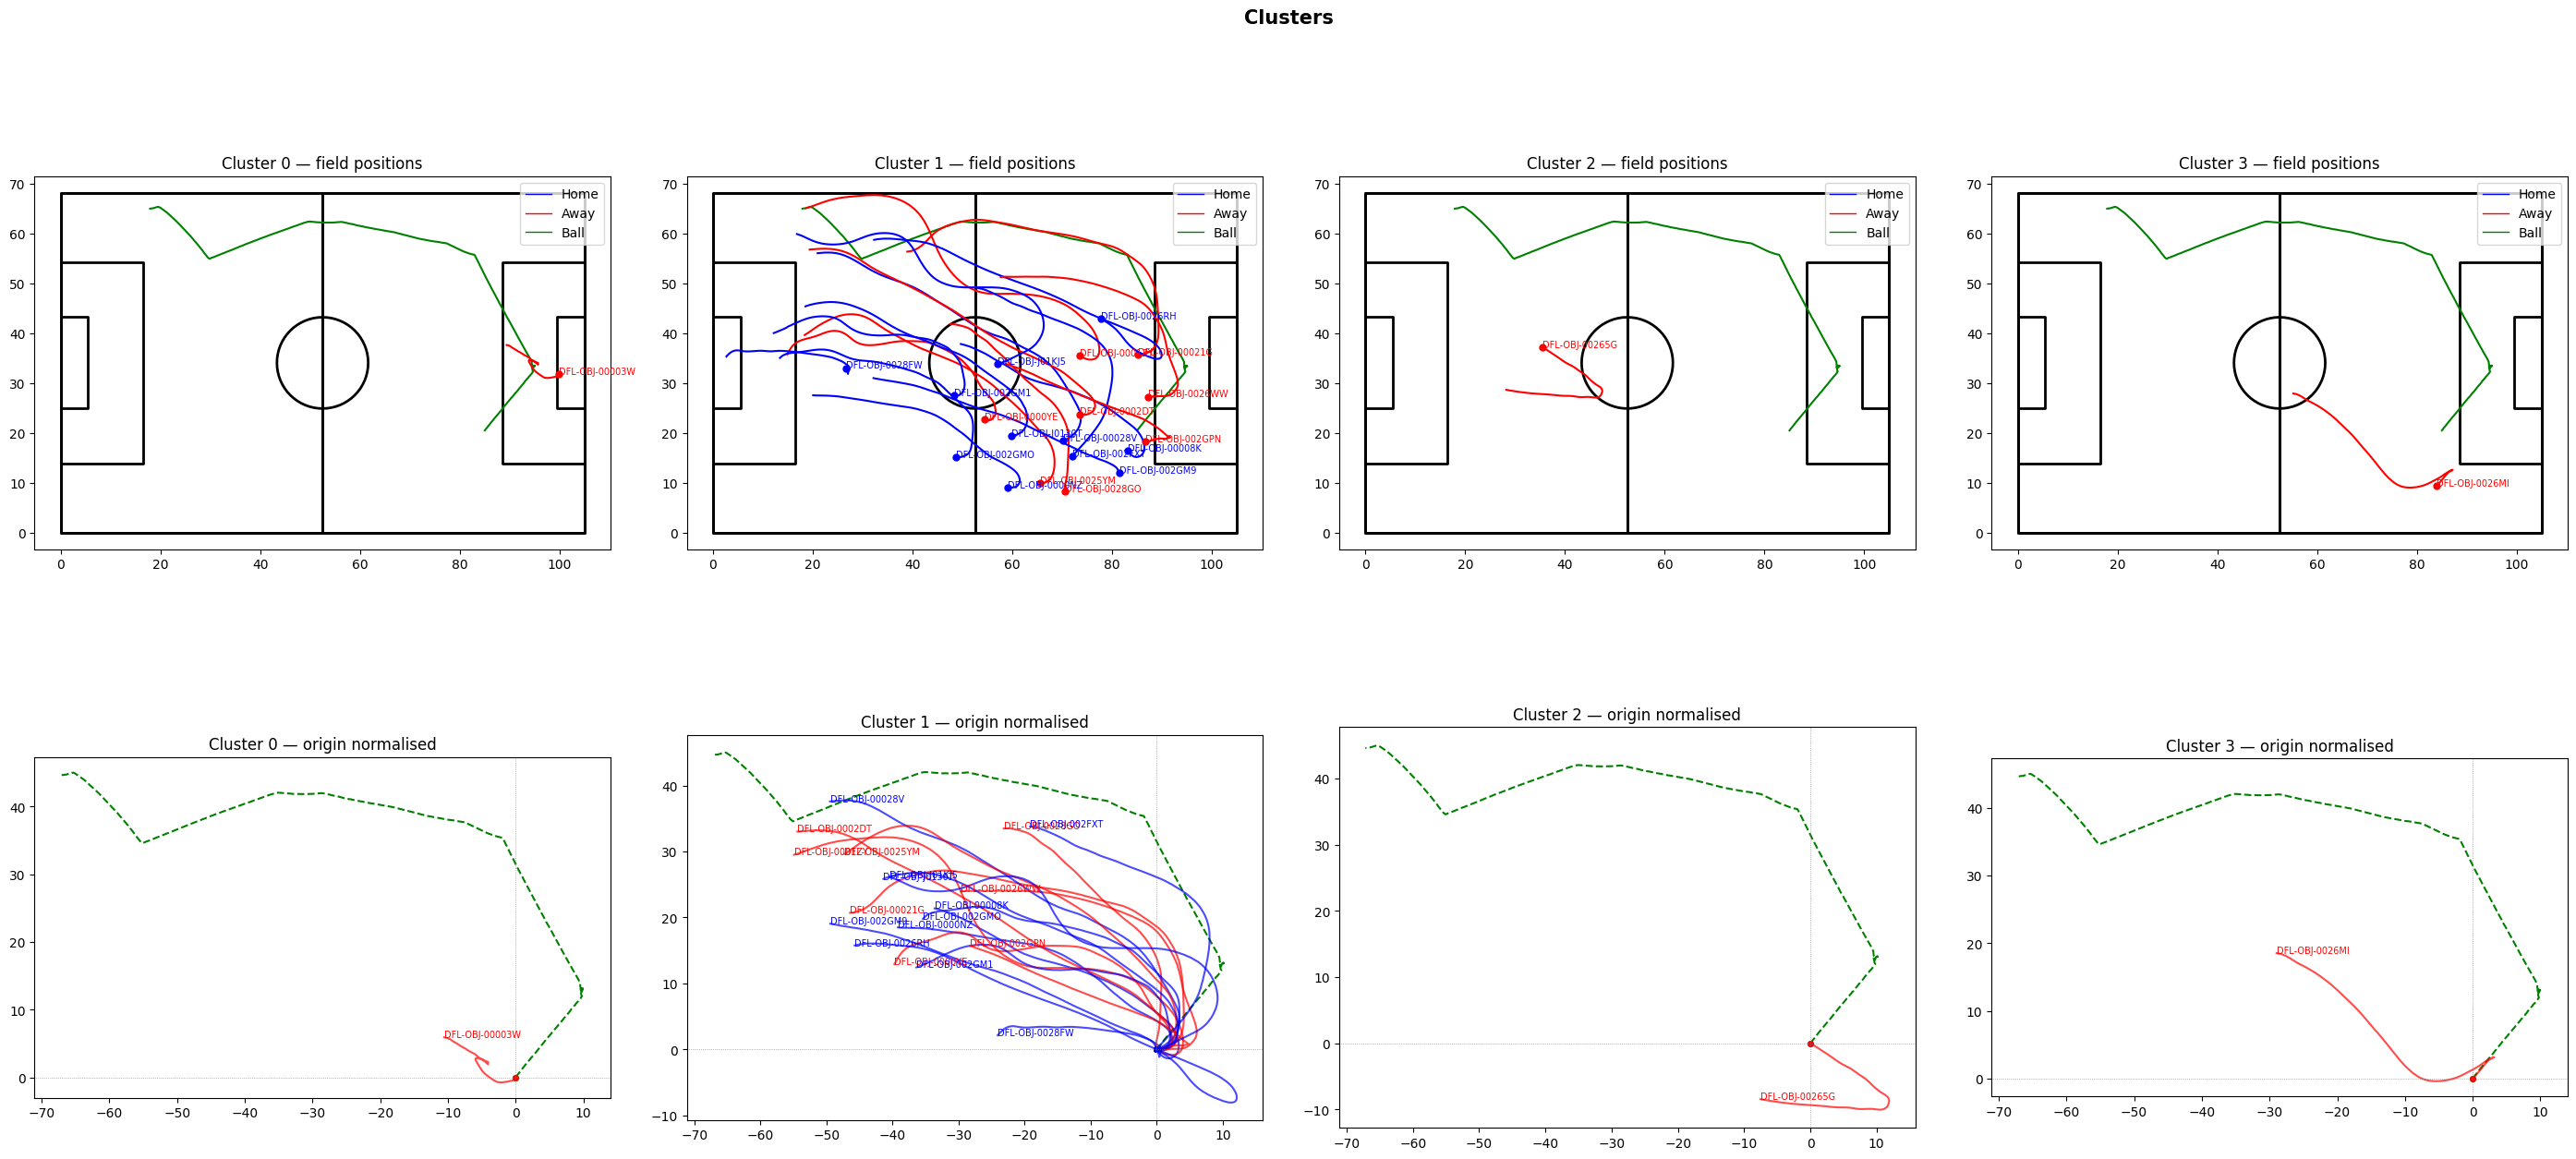


TEAM BREAKDOWN PER CLUSTER
Home_Away     Away  Home  Total
cluster_name                   
Cluster 0        1     0      1
Cluster 1        8    11     19
Cluster 2        1     0      1
Cluster 3        1     0      1

ROLE BREAKDOWN PER CLUSTER
role          Defender  Forward  Goalkeeper  Midfielder  Unknown
cluster_name                                                    
Cluster 0            0        0           1           0        0
Cluster 1            7        2           1           8        1
Cluster 2            0        0           0           1        0
Cluster 3            1        0           0           0        0

ROLE BREAKDOWN PER CLUSTER BY TEAM

  Away
  ------------------------------
role          Defender  Forward  Goalkeeper  Midfielder
cluster_name                                           
Cluster 0            0        0           1           0
Cluster 1            3        1           0           4
Cluster 2            0        0           0           1
Clust

,player,tID,team,role,cluster,is_handling
0,DFL-OBJ-00265G,DFL-CLU-00000I,Away,Midfielder,2,False
1,DFL-OBJ-0026MI,DFL-CLU-00000I,Away,Defender,3,False


In [3]:
flagged, _, _=tc.trajectory_anom_per_possession(GameData, "J03WR9_Away_2", plotting=True, breakdown_report=True)
flagged

In [7]:
GameData.events.query('`case:concept:name`=="J03WR9_Home_99"')

,level_0,concept:name,attribute:gameclock,tID,Player,attribute:outcome,time:timestamp,minute,second,attribute:qualifier,...,pass_distance,pass_angle,ball,attribute:game,case:concept:name,attacking_team,defending_team,Grid Position,attribute:enabled,best_pass
864,480,Pass_Intercepted,1816.397,None,NaN,0.0,2022-11-11 18:01:28.377000+00:00,30.0,16.0,"{'Player': 'DFL-OBJ-00265G', 'Distance': 'long...",...,0.0,0.0,J03WR9,J03WR9,J03WR9_Home_99,NaN,NaN,"(2, 0)",[],False


In [15]:
GameData.events=GameData.events.sort_values(['attribute:session','attribute:frame'])
possession_ids, counts=np.unique(GameData.events['case:concept:name'], return_counts=True)
results = []
for pid, c in zip(possession_ids, counts):
    if c>1:
        flagged, labels, D = tc.trajectory_anom_per_possession(GameData, pid)
        if not flagged.empty:
            flagged["possessionID"] = pid
            results.append(flagged)



  Auto-selected eps=0.2971, silhouette=0.037, clusters=4, outliers=0
FLAGGED PLAYERS (moving differently)

  Cluster 1 (1 players):
    DFL-OBJ-002GM1 — Home, Midfielder

  Cluster 2 (1 players):
    DFL-OBJ-002GM9 — Home, Defender

  Cluster 3 (1 players):
    DFL-OBJ-J01KJ5 — Home, Defender

  Flagged player list: ['DFL-OBJ-002GM1', 'DFL-OBJ-002GM9', 'DFL-OBJ-J01KJ5']


  Auto-selected eps=0.3925, silhouette=0.243, clusters=2, outliers=0
FLAGGED PLAYERS (moving differently)

  Cluster 0: skipped (goalkeepers only)

  No flagged players.


  Auto-selected eps=0.5186, silhouette=0.284, clusters=2, outliers=0
FLAGGED PLAYERS (moving differently)

  Cluster 1 (1 players):
    DFL-OBJ-002GM9 — Home, Defender

  Flagged player list: ['DFL-OBJ-002GM9']


  Auto-selected eps=0.1339, silhouette=0.643, clusters=2, outliers=0
FLAGGED PLAYERS (moving differently)

  Cluster 1 (1 players):
    DFL-OBJ-002GM1 — Home, Midfielder

  Flagged player list: ['DFL-OBJ-002GM1']


  Auto-selected eps=0.356

KeyboardInterrupt: 

In [17]:
all_flagged = pd.concat(results, ignore_index=True) if results else pd.DataFrame()

In [20]:
def report_flagged_summary(all_flagged: pd.DataFrame,
                           pid_col: str = "player",
                           team_col: str = "team",
                           role_col: str = "role",
                           possession_col: str = "possessionID",
                           top_n: int = 3) -> None:

    sep = "=" * 50

    print(sep)
    print(f"TOP {top_n} MOST FLAGGED PLAYERS PER TEAM")
    print(sep)
    player_counts = (all_flagged.groupby([team_col, pid_col])
                                .size()
                                .reset_index(name="count")
                                .sort_values([team_col, "count"], ascending=[True, False]))
    for team, team_df in player_counts.groupby(team_col):
        print(f"\n  {team}")
        print("  " + "-" * 30)
        for _, row in team_df.head(top_n).iterrows():
            print(f"    {row[pid_col]}: {row['count']} times")

    print(f"\n{sep}")
    print(f"TOP {top_n} MOST FLAGGED ROLES PER TEAM")
    print(sep)
    role_counts = (all_flagged.groupby([team_col, role_col])
                              .size()
                              .reset_index(name="count")
                              .sort_values([team_col, "count"], ascending=[True, False]))
    for team, team_df in role_counts.groupby(team_col):
        print(f"\n  {team}")
        print("  " + "-" * 30)
        for _, row in team_df.head(top_n).iterrows():
            print(f"    {row[role_col]}: {row['count']} times")

    print(f"\n{sep}")
    print(f"TOP {top_n} POSSESSIONS WITH MOST FLAGGED PLAYERS")
    print(sep)
    possession_counts = (all_flagged.groupby(possession_col)
                                    .size()
                                    .reset_index(name="count")
                                    .sort_values("count", ascending=False))
    for _, row in possession_counts.head(top_n).iterrows():
        print(f"  {row[possession_col]}: {row['count']} flagged players")

    print(f"\n{sep}\n")
report_flagged_summary(all_flagged, top_n=5)

TOP 5 MOST FLAGGED PLAYERS PER TEAM

  Away
  ------------------------------
    DFL-OBJ-0000YE: 5 times
    DFL-OBJ-0002DT: 4 times
    DFL-OBJ-00265G: 4 times
    DFL-OBJ-0026MI: 3 times
    DFL-OBJ-002GPN: 3 times

  Home
  ------------------------------
    DFL-OBJ-0000NZ: 5 times
    DFL-OBJ-002GM1: 5 times
    DFL-OBJ-J01KJ5: 4 times
    DFL-OBJ-002GM9: 3 times
    DFL-OBJ-002GMO: 3 times

TOP 5 MOST FLAGGED ROLES PER TEAM

  Away
  ------------------------------
    Midfielder: 11 times
    Defender: 7 times
    Forward: 5 times

  Home
  ------------------------------
    Defender: 15 times
    Midfielder: 5 times
    Forward: 2 times
    Goalkeeper: 2 times
    Unknown: 2 times

TOP 5 POSSESSIONS WITH MOST FLAGGED PLAYERS
  J03WR9_Away_138: 8 flagged players
  J03WR9_Away_135: 8 flagged players
  J03WR9_Away_142: 5 flagged players
  J03WR9_Away_126: 4 flagged players
  J03WR9_Away_10: 3 flagged players




In [ ]:
df=GameData.events.query('`case:concept:name`=="J03WR9_Away_2"')
df['attribute:frame']=df['attribute:frame'].astype(int)
#df=df[df["geometry"].isna()]
start_frame, end_frame, session=np.min(df['attribute:frame']),np.max(df['attribute:frame']),np.unique(df['attribute:session'])[0]
print(start_frame, end_frame, session)
ball=GameData.positions.query('`Frame`>=@start_frame & `Frame`<@end_frame & Session==@session')
extract_ball=np.unique(ball['Player'])[0]
ball=ball.query('Player==@extract_ball')[['ball_x','ball_y', 'Frame']]
ball.rename(columns={'ball_x':'x','ball_y':'y'}, inplace=True)
# ball_gdf = gpd.GeoDataFrame(
#     ball,
#     geometry=gpd.points_from_xy(ball["x"], ball["y"])
# )
# ball_line = gpd.GeoDataFrame(
#     geometry=[LineString(zip(ball["x"], ball["y"]))]
# )
# h_df=df.query('`attribute:team`=="Home"')
# a_df=df.query('`attribute:team`=="Away"')
# h_df=gpd.GeoDataFrame(df.query('`attribute:team`=="Home"'),
#     geometry=GameData.events['trajectory'])
# a_df=gpd.GeoDataFrame(df.query('`attribute:team`=="Away"'),
#     geometry=GameData.events['trajectory'])

197 546 1


/var/folders/c4/5rcttgt14hj_p3bnfsdmbmkr0000gn/T/ipykernel_33891/1060154606.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['attribute:frame']=df['attribute:frame'].astype(int)


In [26]:
pass_sub=df.query('ball.notna()')
pass_sub = pass_sub[pass_sub["concept:name"].str.endswith(("Pass", "Cross", "Received", "Intercepted"), na=False)]
handling_players=np.unique(pass_sub['Player'])

In [4]:
session_df=GameData.positions[GameData.positions["Session"] == session]
session_df = session_df.query('Frame<@end_frame & Frame>=@start_frame')
session_df = session_df.sort_values(["Player", "Frame"])

traj_df = (
    session_df.groupby(["Player","Team"])
      .apply(lambda g: LineString(zip(g["x"], g["y"])))
      .reset_index(name="geometry")
)

gdf = gpd.GeoDataFrame(traj_df, geometry="geometry")
home = gdf[gdf["Team"] == "Home"]
away = gdf[gdf["Team"] == "Away"]

/var/folders/c4/5rcttgt14hj_p3bnfsdmbmkr0000gn/T/ipykernel_33891/3143452474.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: LineString(zip(g["x"], g["y"])))


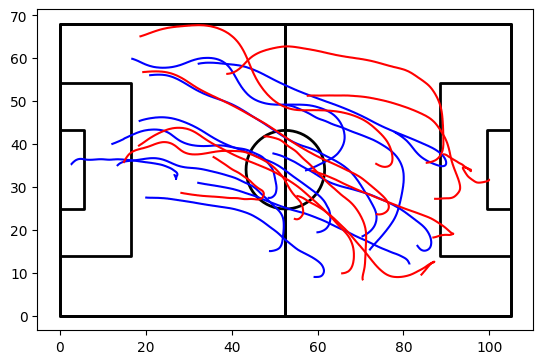

In [7]:
fig, ax= plt.subplots()
plot.plot_background_ax(ax)
plot.plot_trace(home, ax, 'blue')
plot.plot_trace(away, ax, 'red')


In [ ]:
players = {
    pid: grp.sort_values("Frame")[["x", "y"]].values
    for pid, grp in session_df.groupby("Player")
}
ball_ar = ball.sort_values("Frame")[["x", "y"]].values


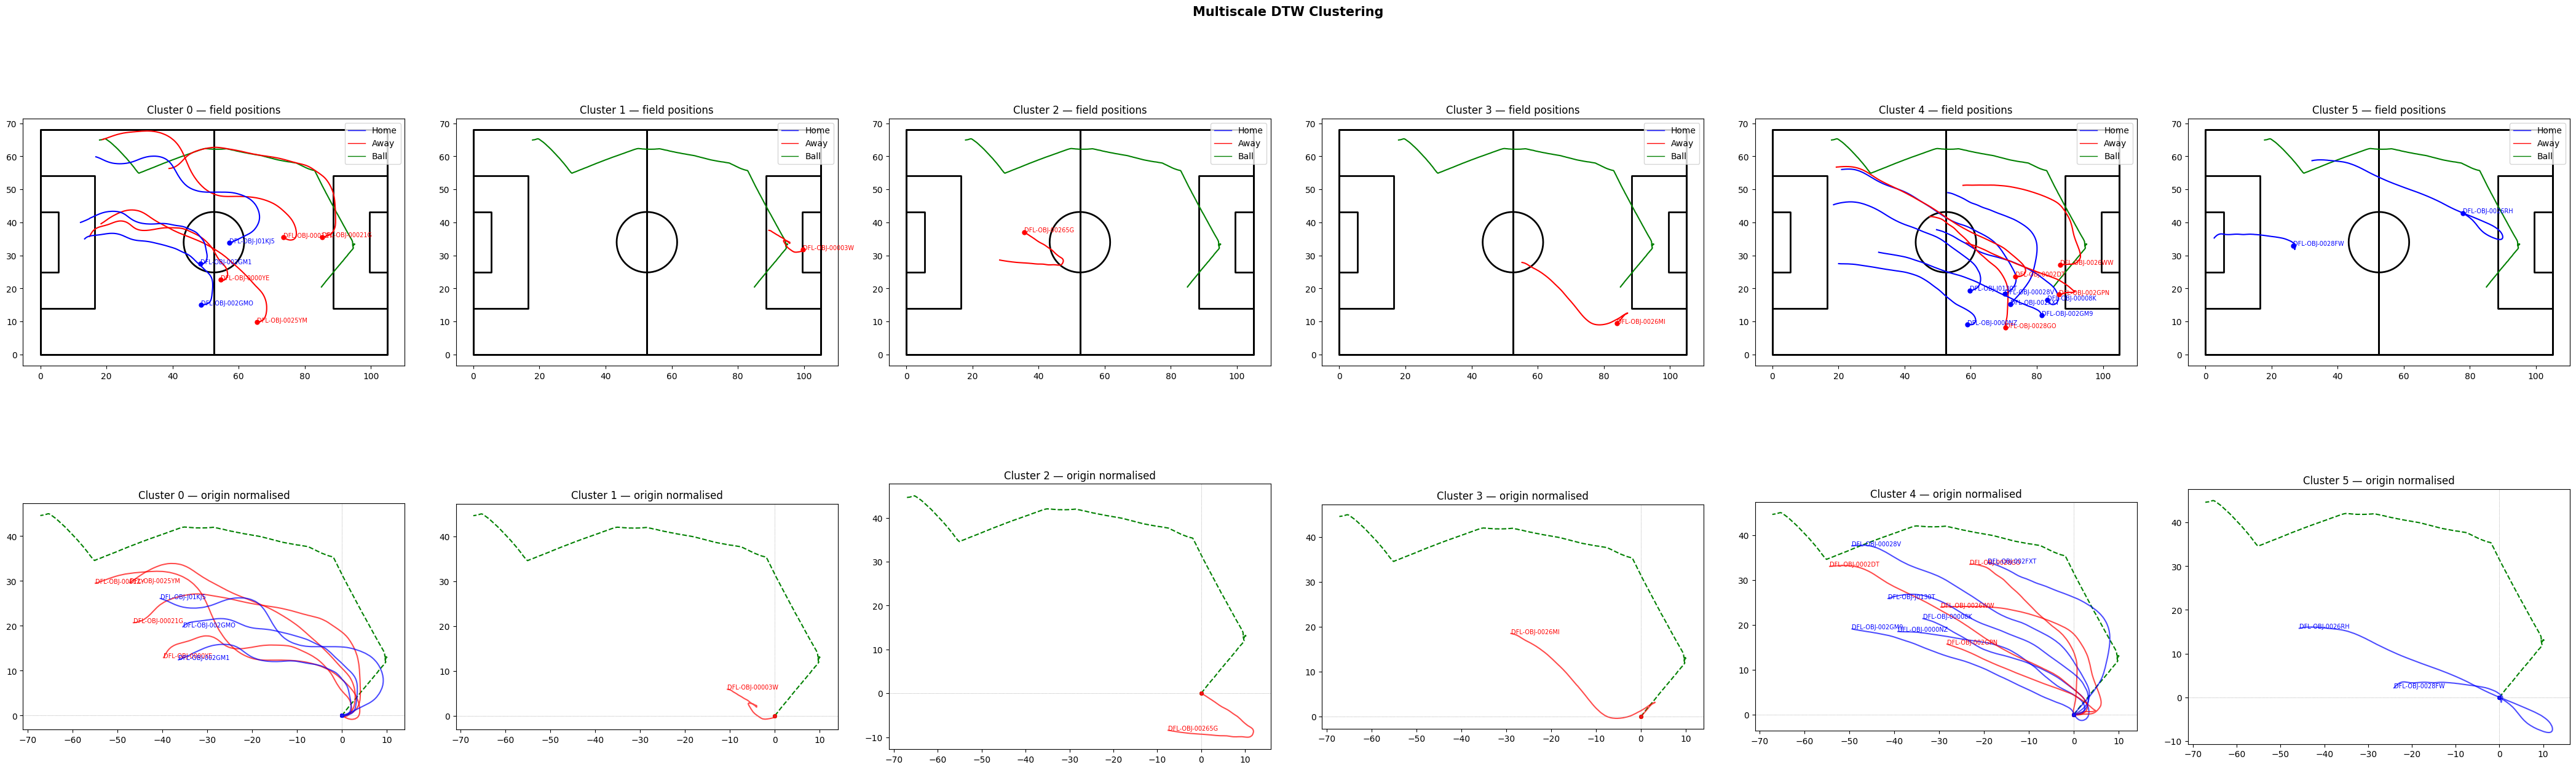

In [ ]:
labels, D, ids = tc.cluster_multivariate(players, ball_ar, n_clusters=6, weights=np.array([1,0]))
team_map = session_df.drop_duplicates("Player").set_index("Player")["Team"].to_dict()

fig = tc.plot_clusters(players, ball_ar, labels, team_map,
                    title="Multivariate DTW Clustering")
plt.show()

  Auto-selected eps=0.1220, silhouette=0.352, clusters=5, outliers=0


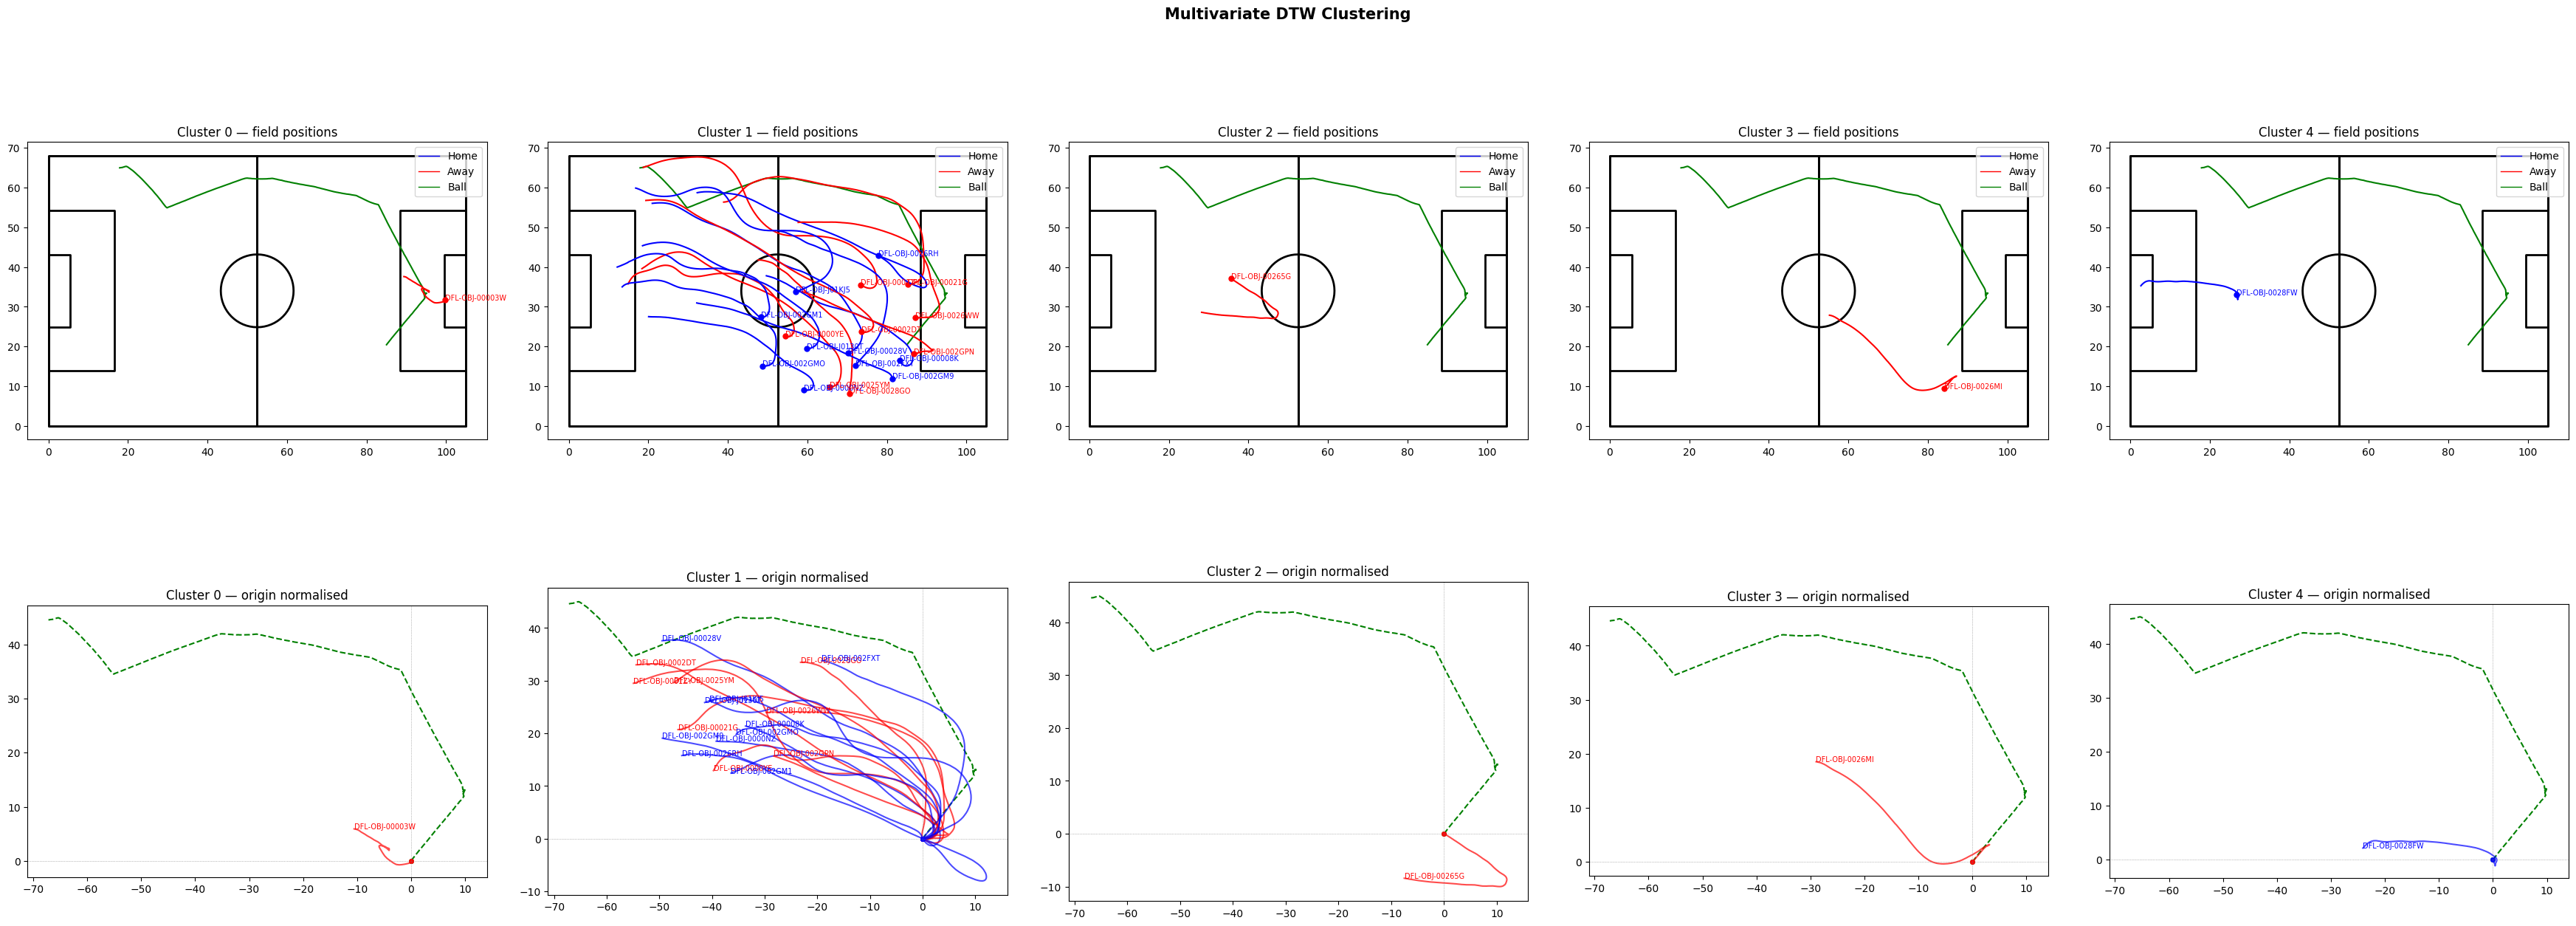

In [38]:
def get_multivariate_distance_matrix(players: dict[str, np.ndarray],
                                      ball: np.ndarray,
                                      weights: np.ndarray = None) -> tuple:
    if weights is None:
        weights = np.array([0.5, 0.5])

    mv_signals = tc.build_multivariate_signals(players, ball)
    return tc.build_multivariate_distance_matrix(mv_signals, weights)
ids_mv, D_mv = get_multivariate_distance_matrix(players, ball, weights=np.array([0.5, 0.5]))
def normalise_distance_matrix(D: np.ndarray) -> np.ndarray:
    max_d = D.max()
    if max_d == 0:
        return D
    return D / max_d
D_norm = normalise_distance_matrix(D)
labels_db = tc.auto_cluster_dbscan(D_norm, ids, min_samples=1)
team_map = session_df.drop_duplicates("Player").set_index("Player")["Team"].to_dict()
fig = tc.plot_clusters(players, ball_ar, labels_db, team_map,
                    title="Multivariate DTW Clustering")
plt.show()

In [39]:
analyse_clusters(labels_db, GameData.team_sheets_df)


TEAM BREAKDOWN PER CLUSTER
Home_Away     Away  Home  Total
cluster_name                   
Cluster 0        1     0      1
Cluster 1        8    10     18
Cluster 2        1     0      1
Cluster 3        1     0      1
Cluster 4        0     1      1

ROLE BREAKDOWN PER CLUSTER
role          Defender  Forward  Goalkeeper  Midfielder  Unknown
cluster_name                                                    
Cluster 0            0        0           1           0        0
Cluster 1            7        2           0           8        1
Cluster 2            0        0           0           1        0
Cluster 3            1        0           0           0        0
Cluster 4            0        0           1           0        0

ROLE BREAKDOWN PER CLUSTER BY TEAM

  Away
  ------------------------------
role          Defender  Forward  Goalkeeper  Midfielder
cluster_name                                           
Cluster 0            0        0           1           0
Cluster 1           

In [40]:
flagged = flag_players(labels_db, GameData.team_sheets_df, handling_players)

FLAGGED PLAYERS (moving differently)

  Cluster 0: skipped (goalkeepers only)

  Cluster 2 (1 players):
    DFL-OBJ-00265G — Away, Midfielder

  Cluster 3 (1 players):
    DFL-OBJ-0026MI — Away, Defender

  Cluster 4: skipped (goalkeepers only)

  Flagged player list: ['DFL-OBJ-00265G', 'DFL-OBJ-0026MI']


